In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.Timestamp('6th jan 2023 8:10')

Timestamp('2023-01-06 08:10:00')

In [3]:
pd.DatetimeIndex([pd.Timestamp('6th jan 2023 8:10'),pd.Timestamp('7th jan 2023 8:10'),pd.Timestamp('8th jan 2023 8:10')])[0]

Timestamp('2023-01-06 08:10:00')

In [4]:
pd.date_range(start='2023-1-6',end='2023-1-31',freq='D')

DatetimeIndex(['2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09',
               '2023-01-10', '2023-01-11', '2023-01-12', '2023-01-13',
               '2023-01-14', '2023-01-15', '2023-01-16', '2023-01-17',
               '2023-01-18', '2023-01-19', '2023-01-20', '2023-01-21',
               '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25',
               '2023-01-26', '2023-01-27', '2023-01-28', '2023-01-29',
               '2023-01-30', '2023-01-31'],
              dtype='datetime64[ns]', freq='D')

In [6]:
s = pd.Series(['2023/1/6','2023/1/7','2023/1/7'])
pd.to_datetime(s).dt.day_name()

0      Friday
1    Saturday
2    Saturday
dtype: object

In [7]:
pd.Timedelta(days=2,hours=10,minutes=35)

Timedelta('2 days 10:35:00')

In [8]:
pd.Timestamp('6th jan 2023') + pd.Timedelta(days=2,hours=10,minutes=35)

Timestamp('2023-01-08 10:35:00')

In [9]:
pd.date_range(start='2023-1-6',end='2023-1-31',freq='D') - pd.Timedelta(days=2,hours=10,minutes=35)

DatetimeIndex(['2023-01-03 13:25:00', '2023-01-04 13:25:00',
               '2023-01-05 13:25:00', '2023-01-06 13:25:00',
               '2023-01-07 13:25:00', '2023-01-08 13:25:00',
               '2023-01-09 13:25:00', '2023-01-10 13:25:00',
               '2023-01-11 13:25:00', '2023-01-12 13:25:00',
               '2023-01-13 13:25:00', '2023-01-14 13:25:00',
               '2023-01-15 13:25:00', '2023-01-16 13:25:00',
               '2023-01-17 13:25:00', '2023-01-18 13:25:00',
               '2023-01-19 13:25:00', '2023-01-20 13:25:00',
               '2023-01-21 13:25:00', '2023-01-22 13:25:00',
               '2023-01-23 13:25:00', '2023-01-24 13:25:00',
               '2023-01-25 13:25:00', '2023-01-26 13:25:00',
               '2023-01-27 13:25:00', '2023-01-28 13:25:00'],
              dtype='datetime64[ns]', freq='D')

In [11]:
df = pd.read_csv('deliveries_dates.csv')
df.head()

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98


In [12]:
df['order_date']=pd.to_datetime(df['order_date'])

C:\Users\swaya\AppData\Local\Temp\ipykernel_17316\2992783237.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date']=pd.to_datetime(df['order_date'])


In [14]:
df['delivery_date']=pd.to_datetime(df['delivery_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_date     501 non-null    datetime64[ns]
 1   delivery_date  501 non-null    datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 8.0 KB


C:\Users\swaya\AppData\Local\Temp\ipykernel_17316\1737592039.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_date']=pd.to_datetime(df['delivery_date'])


In [15]:
df['delivery_time']=df['delivery_date']-df['order_date']

In [17]:
df['delivery_time'].mean()

Timedelta('1217 days 22:53:53.532934128')

## Time Series

In [18]:
google=pd.read_csv('google.csv')

In [26]:
login=pd.read_csv('login.csv',header=None)
login.head()
login.columns = ['Start', 'id', 'end', 'IP-Add']
login.head()

,Start,id,end,IP-Add
0,1,466,2017-01-07 18:24:07,Unnamed: 3
1,2,466,2017-01-07 18:24:55,NaN
2,3,458,2017-01-07 18:25:18,NaN
3,4,458,2017-01-07 18:26:21,NaN
4,5,592,2017-01-07 19:09:59,NaN


In [28]:
google['Date'] = pd.to_datetime(google['Date'])
login['Start'] = pd.to_datetime(login['Start'])

In [31]:
login['end']=pd.to_datetime(login['end'])

In [32]:
login.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3003 entries, 0 to 3002
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Start   3003 non-null   datetime64[ns]
 1   id      3003 non-null   int64         
 2   end     3003 non-null   datetime64[ns]
 3   IP-Add  2210 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 94.0+ KB


In [33]:
google['Date']=pd.to_datetime(google['Date'])

In [34]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[ns]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   float64       
 6   Volume     4471 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 244.6 KB


In [35]:
google

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276
...,...,...,...,...,...,...,...
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600


In [36]:
# challenge -> fetch info for a particular date every year -> limitation of timedelta
google.head()


google[google.index.isin(pd.date_range(start='2005-1-6',end='2022-1-6',freq=pd.DateOffset(years=1)))]

,Date,Open,High,Low,Close,Adj Close,Volume


<Axes: xlabel='Date'>

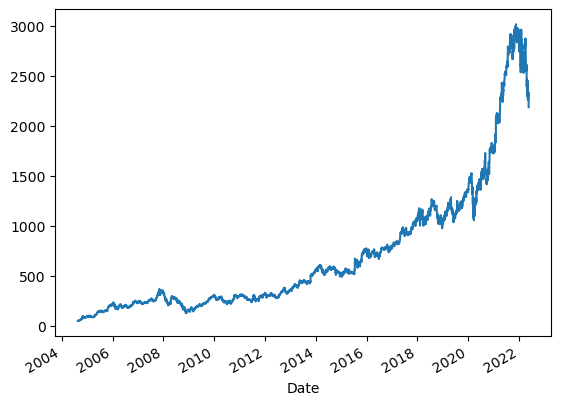

In [40]:
google=google.set_index('Date')
google['Close'].plot()

<Axes: xlabel='Date'>

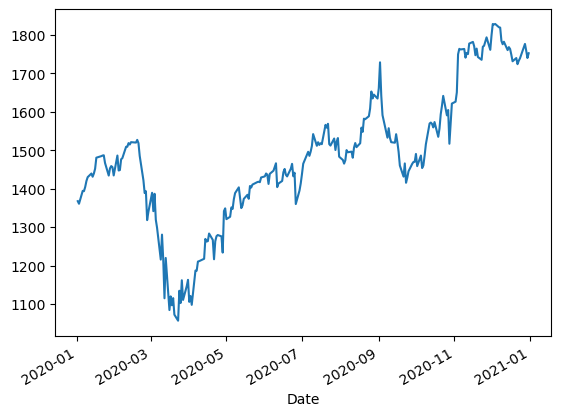

In [48]:
google.loc['2020']['Close'].plot()

<Axes: xlabel='month_name'>

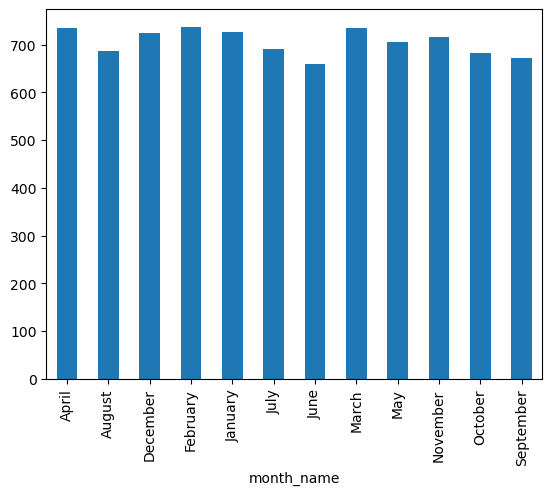

In [53]:
google.groupby('month_name')['Close'].mean().plot(kind='bar')

In [52]:
google['month_name'] = google.index.month_name()
google.head()

,Open,High,Low,Close,Adj Close,Volume,month_name
Date,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August


In [55]:
google['quarter'] = google.index.quarter
google.head()

,Open,High,Low,Close,Adj Close,Volume,month_name,quarter
Date,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,3


<Axes: xlabel='quarter'>

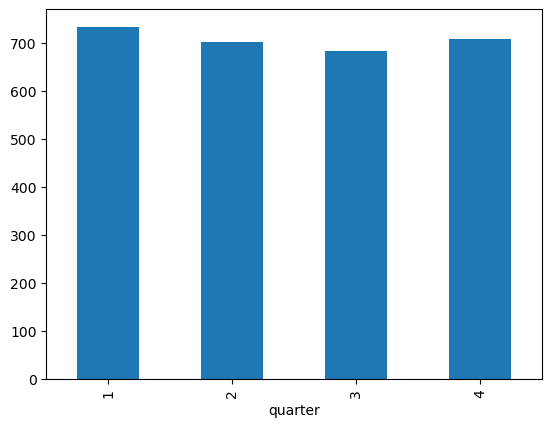

In [56]:
google.groupby('quarter')['Close'].mean().plot(kind='bar')

In [57]:
google.index

DatetimeIndex(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
               '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30',
               '2004-08-31', '2004-09-01',
               ...
               '2022-05-09', '2022-05-10', '2022-05-11', '2022-05-12',
               '2022-05-13', '2022-05-16', '2022-05-17', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[ns]', name='Date', length=4471, freq=None)

In [58]:
google.asfreq('6h',method='bfill')

,Open,High,Low,Close,Adj Close,Volume,month_name,quarter
Date,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,3
2004-08-19 06:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,3
2004-08-19 12:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,3
2004-08-19 18:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,3
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,3
...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,2
2022-05-19 06:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100,May,2
2022-05-19 12:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100,May,2


In [59]:
login

,Start,id,end,IP-Add
0,1970-01-01 00:00:00.000000001,466,2017-01-07 18:24:07,Unnamed: 3
1,1970-01-01 00:00:00.000000002,466,2017-01-07 18:24:55,NaN
2,1970-01-01 00:00:00.000000003,458,2017-01-07 18:25:18,NaN
3,1970-01-01 00:00:00.000000004,458,2017-01-07 18:26:21,NaN
4,1970-01-01 00:00:00.000000005,592,2017-01-07 19:09:59,NaN
...,...,...,...,...
2998,1970-01-01 00:00:00.000002999,1307,2018-01-04 10:48:28,183.82.121.201
2999,1970-01-01 00:00:00.000003000,1230,2018-01-04 11:22:00,47.247.147.114
3000,1970-01-01 00:00:00.000003001,1307,2018-01-04 13:13:44,183.82.121.201
3001,1970-01-01 00:00:00.000003002,1307,2018-01-04 13:13:45,183.82.121.201


In [60]:
user_df = login[login['id'] == 458]
user_df.head()

,Start,id,end,IP-Add
2,1970-01-01 00:00:00.000000003,458,2017-01-07 18:25:18,NaN
3,1970-01-01 00:00:00.000000004,458,2017-01-07 18:26:21,NaN
9,1970-01-01 00:00:00.000000010,458,2017-01-09 11:13:12,NaN
10,1970-01-01 00:00:00.000000011,458,2017-01-09 11:34:02,NaN
25,1970-01-01 00:00:00.000000026,458,2017-01-10 12:14:11,NaN


In [61]:
user_df['shifted'] = user_df['Start'].shift(1)

C:\Users\swaya\AppData\Local\Temp\ipykernel_17316\3462353539.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['shifted'] = user_df['Start'].shift(1)


In [62]:
(user_df['Start']-user_df['shifted']).mean()

Timedelta('0 days 00:00:00.000000004')